# Assignment 1 - Scoring, k-NN and linear regression

Use `random_state=42` for every scikit-learn call and `np.random.seed(42)` as the global seed, so that your results are reproducible (both explained in `ch1`). **Every result requires commentary from you and interpretation where possible using markdown cells!**. Save the notebook with outputs
(Run All, then save) before submitting.


## Task 1 - Score a confusion matrix by hand

A volunteer is looking for a few missing cats in a neighbourhood full of stray dogs.
A binary classifier has classes "cat" (positive) and "dog" (negative). The truth and its
guesses are given below. Compute **accuracy, precision, recall and F1** using scikit-learn
and print all four. In one sentence, state why a missed cat is worse than a false alarm.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = [0, 1, 1, 0, 1, 0, 1, 0, 1, 0]
y_pred = [0, 1, 0, 0, 1, 1, 1, 0, 0, 0]

# TODO: compute the four metrics and print them.

accuracy = None
precision = None
recall = None
f1 = None

# ---- YOUR CODE HERE ----
accuracy = accuracy_score(y_true , y_pred) 
precision = precision_score(y_true, y_pred) 
recall = recall_score(y_true, y_pred) 
f1 = f1_score(y_true, y_pred) 
# ------------------------

print(f"accuracy  = {accuracy}")
print(f"precision = {precision}")
print(f"recall    = {recall}")
print(f"f1        = {f1}")


#COMMENT: 
# ------------------------
# A false negative provide sense of security, saying a problem is NOT there when it actually is
# A missed cat is a false negative and worse that a false alarm,its saying the cat is NOT there
#  when it is. 
# This might lead to that cat never discovered. 

accuracy  = 0.7
precision = 0.75
recall    = 0.6
f1        = 0.6666666666666666


In [4]:
# CHECK (Task 1) - run after your code. Guardrails, not exact targets.
assert accuracy is not None, "compute accuracy first"
assert 0.5 < accuracy < 1.0, "accuracy should be between 0.5 and 1.0"
assert 0.0 <= precision <= 1.0
assert 0.0 <= recall <= 1.0
assert 0.0 <= f1 <= 1.0
print("Task 1 checks passed.")


Task 1 checks passed.


## Task 2 - k-NN on the Iris dataset

Train a `KNeighborsClassifier` on Scikit's Iris dataset for three values of k, i.e. k=3,
k=5 and k=15, and report the **test accuracy** for each. Split the data with
`train_test_split` 80/20 (`random_state=42`). State which k does best.

Iris is an easy, clean dataset, so all three k values may score near 1.0. Which k would you
expect to do best on a harder, noisier dataset? Discuss in bias-variance terms, referring
to `ch1`.


In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 


# TODO: loop over k in [3, 5, 15], fit a KNeighborsClassifier(k), print test accuracy for each.

accs = []

# ---- YOUR CODE HERE ----

for k in [3, 5, 15]: 
    model = KNeighborsClassifier(k)
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test) 
    accs.append(accuracy_score(y_test, y_pred)) 

# ------------------------

for k, a in zip([3, 5, 15], accs):
    print(f"k={k:2d}: test accuracy = {a:.3f}")


#COMMENT: 
# ------------------------
# I would expect k = 5 to behave better that k = 1 and k = 15. A small k follows every point, 
# low bias, high variance and overfit boundary,
#  while a large k averages accross classes, high bias, low variance but an underfit boundary. 
#  So I would expect k = 5 to perform better even with a larger dataset. 


k= 3: test accuracy = 1.000
k= 5: test accuracy = 1.000
k=15: test accuracy = 1.000


In [7]:
# CHECK (Task 2)
assert len(accs) == 3, "store exactly 3 accuracies (one per k value)"
assert all(0.6 < a <= 1.0 for a in accs), "each accuracy should be between 0.6 and 1.0"
best_k = [3, 5, 15][accs.index(max(accs))]
print(f"Task 2 checks passed. Best k in your run: {best_k} (accuracy {max(accs):.3f}).")


Task 2 checks passed. Best k in your run: 3 (accuracy 1.000).


## Task 3 - Linear regression on the housing data

Load `housingdata.csv` (it has **no header row**). Predict the median house price (column
13) from the average number of rooms (column 5). Split the data with `train_test_split`
80/20 (`random_state=42`), fit a `LinearRegression`, and report the **test $R^2$**.

Rooms alone is a weak predictor of price, so the test $R^2$ lands well below 1. Explain why
a single feature cannot capture the spread of house prices effectively.


Research this dataset, especially for Task 4. Here is the gist for the missing header row:

| Col | Feature  | Description                                                          |
|-----|----------|----------------------------------------------------------------------|
| 0   | CRIM     | Crime rate per person by town.                                       |
| 1   | ZN       | Residential land share (lots over 25,000 sq. ft.).                  |
| 2   | INDUS    | Non-retail business land share by town.                              |
| 3   | CHAS     | Charles River indicator (1 if next to river; 0 if not).              |
| 4   | NOX      | Nitric oxide air pollution (parts per 10 million).                   |
| 5   | RM       | Average room count per home.                                         |
| 6   | AGE      | Share of older homes built before 1940.                              |
| 7   | DIS      | Weighted distance to five job hubs in Boston.                        |
| 8   | RAD      | Highway access score.                                                |
| 9   | TAX      | Property tax rate per $10,000.                                       |
| 10  | PTRATIO  | Student-to-teacher ratio by town.                                     |
| 11  | B        | 1000(Bk - 0.63)² where Bk is the Black population share by town.     |
| 12  | LSTAT    | Share of lower-status residents (percent).                          |
| 13  | MEDV     | Median home price in thousands of dollars (target to predict).      |


In [34]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score 

housing = pd.read_csv("housingdata.csv", header=None, names=["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"])
X = housing[ ["RM"] ].values #Recall that X must be multidimensional 
y = housing["MEDV"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

# TODO: fit a LinearRegression and compute the test R^2 (use .score).

r2 = None

# ---- YOUR CODE HERE ----

model = LinearRegression() 
model.fit(X_train, y_train)


r2 = model.score(X_test, y_test)


# ------------------------

print(f"test R^2 = {r2:.3f}")


test R^2 = 0.371


In [13]:
# CHECK (Task 3)
assert r2 is not None, "compute r2 first"
assert 0.2 < r2 < 0.7, "R^2 from rooms alone should be roughly between 0.2 and 0.7"
print(f"Task 3 checks passed. Your test R^2 = {r2:.3f}.")


Task 3 checks passed. Your test R^2 = 0.371.


## Task 4 - Linear regression with all features

Extend Task 3: use **all input features** to predict the median house price, and report the
test $R^2$. Then use a **pairplot** (Seaborn) to select the features you deem most important,
fit a new `LinearRegression` with just those features, and report that $R^2$ too.

Justify your selected features and describe what you observe from the three test $R^2$ results
(Task 3 rooms-only, all features, selected features).


all features R^2 = 0.669
selected features R^2 = 0.556


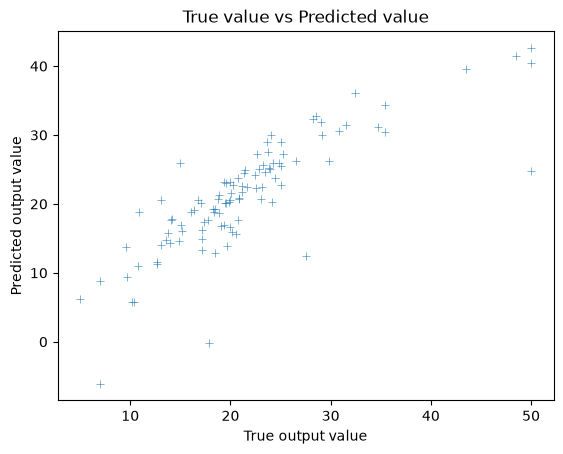

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# TODO: fit LinearRegression on ALL features, report test R^2
# all_r2 = None
# YOUR CODE HERE

all_X = housing.drop(columns=["MEDV"]) 
selected_X = housing[ ["CRIM", "LSTAT", "RM", "AGE"] ]
y = housing["MEDV"] 

all_X_train, all_X_test, all_y_train, all_y_test = train_test_split(all_X, y, test_size = 0.2, random_state=42) 
selected_X_train, selected_X_test, selected_y_train, selected_y_test = train_test_split(selected_X, y, test_size = 0.2, random_state=42) 

accs = [] 

model = LinearRegression() 

model.fit(all_X_train, all_y_train) 
accs.append(model.score(all_X_test, all_y_test))

model.fit(selected_X_train, selected_y_train)
accs.append(model.score(selected_X_test, selected_y_test))



all_r2 = accs[0]
selected_r2 = accs[1]
# TODO: pairplot to select features, fit on selected features, report R^2
# selected_r2 = None
# YOUR CODE HERE

print(f"all features R^2 = {all_r2:.3f}")
print(f"selected features R^2 = {selected_r2:.3f}")


sns.scatterplot(x= y_test, y=y_pred, marker="+", alpha=0.8)
plt.xlabel("True output value")
plt.ylabel("Predicted output value")
plt.title("True value vs Predicted value")
plt.show()


#I observe that the R2 score is much lower (0.371) in the case where I used less featurers. 
#And much higher when I have used all the features. Selecting few keeps the R2 score somewhere in the middle. 
# I want to assume that the less features you choose, the better is the accuracy of the model depending on how influencial the choice of the features 
# is to what i am trying to predict.

In [33]:
# CHECK (Task 4)
assert "all_r2" in dir() and all_r2 is not None, "compute all_r2 first"
assert "selected_r2" in dir() and selected_r2 is not None, "compute selected_r2 first"
assert 0 < all_r2 < 1.0, "all-features R^2 should be between 0 and 1"
assert 0 < selected_r2 < 1.0, "selected-features R^2 should be between 0 and 1"
print(f"Task 4 checks passed. all={all_r2:.3f}, selected={selected_r2:.3f}.")


Task 4 checks passed. all=0.669, selected=0.556.
